# Physics Informed Neural Networks and Deep Operator Network for beginners

#### by [Francisco Periago](https://multisimo.com/fpe/)

### Experiment 2: PINN approximation of the solution to the exact controllability problem

Compute $u(t)$ such that the solution $y(x, t)$ of the problem

\begin{equation*}
		\left\{\begin{array}{ll}
		y_{tt}- y_{xx}=0, & \text{in } (0,1)\times (0, 2) \\
		y(x,0)=\sin(\pi x), & \text{in } (0, 1) \\
		y_t(x,0)=0 & \text{in } (0, 1)  \\
		y(0,t)=0, & \text{on } \left(0,2\right) \\
		y(1,t)=u(t) & \text{on }   \left(0,2\right)
	\end{array}	
	\right.
\end{equation*}
satifies
$$
y(x, 2) = y_t(x, 2) =0.
$$

This problem has an exact solution which can be obtained trough D'Alembert formula. Indeed, by considering the function
$$
\tilde{y^0}(x)=\left\{\begin{array}{ll}
	\sin\left(\pi x\right) & -1\leq x\leq 1\\
	0 & \text{elsewhere, }
\end{array}
\right.
$$ 
the explicit exact state is given by
\begin{equation}
	y(x,t)=\frac{1}{2}\left(\tilde{y^0}(x-t)+\tilde{y^0}(x+t)\right),\quad 0\leq x\leq 1, \,\, 0\leq t\leq 2,
\end{equation}
and the exact control is 
$$
	u(t)=\left\{\begin{array}{ll}
		\frac{1}{2}y^0\left(1-t\right)  & 0\leq t\leq 1 \\
		& \\
		-\frac{1}{2}y^0\left(t-1\right) & 1\leq t\leq 2.
	\end{array}		
	\right.
$$



In [1]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import deepxde as dde

Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Instructions for updating:
non-resource variables are not supported in the long term



Let's define the PDE 

In [2]:

def pde(x, y): # wave equation
    dy_tt = dde.grad.hessian(y, x, i=1, j=1)
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    return dy_tt -dy_xx



The geometry is the rectangle $[0, 1] \times [0, 2]$. The spatial variable $x\in [0, 1]$ and the time variable $t\in [0, 2]$

In [3]:
geom = dde.geometry.Rectangle(xmin=[0, 0], xmax=[1, 2])

Now, boundary conditions, initial conditions, and **terminal conditions**. No condition is imposed in $x=1$ since the control, which acts at that position, will be obtained as the trace of the solution of the PDE

In [4]:
def initial_pos(x): # initial position
    return np.sin(np.pi * x[:, 0:1])

def initial_velo(x): # initial velocity
    return 0.

def boundary_left(x, on_boundary): # boundary x=0
    return on_boundary and np.isclose(x[0], 0)    

def boundary_bottom(x, on_boundary): # boundary t=0
    return (
        on_boundary 
            and np.isclose(x[1],0)
            and not np.isclose(x[0], 0)
            and not np.isclose(x[0], 1)
            )
    
def boundary_upper(x, on_boundary): #boundary t=2
    return (
        on_boundary
            and np.isclose(x[1],2)
            and not np.isclose(x[0], 0)
            and not np.isclose(x[0], 1)
            )

bc1 = dde.DirichletBC(geom, lambda x: 0, boundary_left)
bc2 = dde.DirichletBC(geom, initial_pos, boundary_bottom)
bc3 = dde.NeumannBC(geom, initial_velo, boundary_bottom)
bc4 = dde.DirichletBC(geom, lambda x: 0, boundary_upper)
bc5 = dde.NeumannBC(geom, lambda x: 0, boundary_upper)

We proceed with the data, net, model, and training

Compiling model...
Building feed-forward neural network...
'build' took 0.062902 s



c:\Users\Periago\anaconda3\envs\deeponetcontrol\lib\site-packages\deepxde\nn\tensorflow_compat_v1\fnn.py:116: UserWarning: `tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.
  return tf.layers.dense(


'compile' took 0.644939 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [6.83e-04, 1.45e-01, 7.16e-01, 1.09e-01, 3.95e-01, 3.04e-02]    [7.04e-04, 1.45e-01, 7.16e-01, 1.09e-01, 3.95e-01, 3.04e-02]    []  
1000      [2.73e-03, 1.29e-03, 3.72e-02, 1.40e-03, 1.18e-04, 5.83e-04]    [2.05e-03, 1.29e-03, 3.72e-02, 1.40e-03, 1.18e-04, 5.83e-04]    []  
2000      [7.01e-04, 1.01e-03, 8.38e-04, 1.84e-04, 2.27e-04, 1.35e-03]    [1.06e-03, 1.01e-03, 8.38e-04, 1.84e-04, 2.27e-04, 1.35e-03]    []  
3000      [2.44e-04, 3.17e-04, 1.15e-04, 6.11e-06, 8.09e-05, 1.01e-04]    [3.26e-04, 3.17e-04, 1.15e-04, 6.11e-06, 8.09e-05, 1.01e-04]    []  
4000      [8.53e-05, 1.22e-04, 4.61e-05, 2.10e-05, 2.32e-05, 4.77e-05]    [3.15e-04, 1.22e-04, 4.61e-05, 2.10e-05, 2.32e-05, 4.77e-05]    []  
5000      [9.44e-04, 3.50e-04, 6.32e-05, 2.00e-03, 7.15e-04, 5.15e-05]    [1.26e-03, 3.50

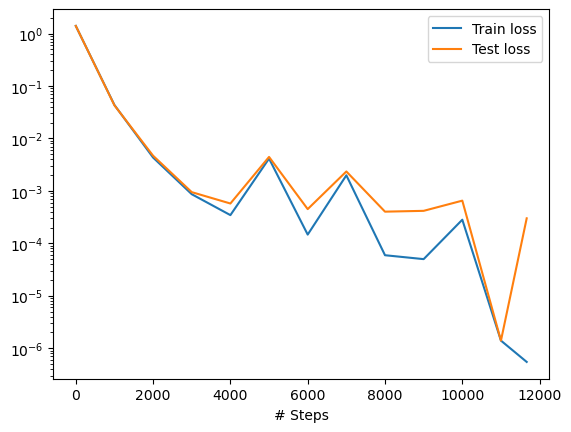

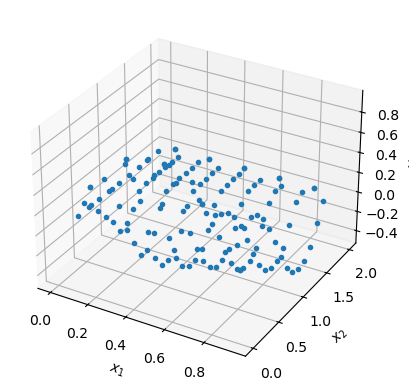

In [5]:
data = dde.data.PDE(
    geom, 
    pde, 
    [bc1, bc2, bc3, bc4, bc5],         
    num_domain=100, 
    num_boundary=30,
    num_test=100
    )

    # training with regularization    
    # net = dde.maps.FNN([2] + [50] * 4 + [1], "tanh", "Glorot uniform", regularization = ['l2',1e-7])

net = dde.maps.FNN([2] + [50] * 4 + [1], "tanh", "Glorot uniform")
model = dde.Model(data, net)

model.compile("adam", lr=0.001)
model.train(epochs=10000)
model.compile("L-BFGS-B")
losshistory, train_state = model.train()
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

### Post-processing: error analysis and figures

generalization error =  0.1498471821998973
relative error =  0.04259670211851704


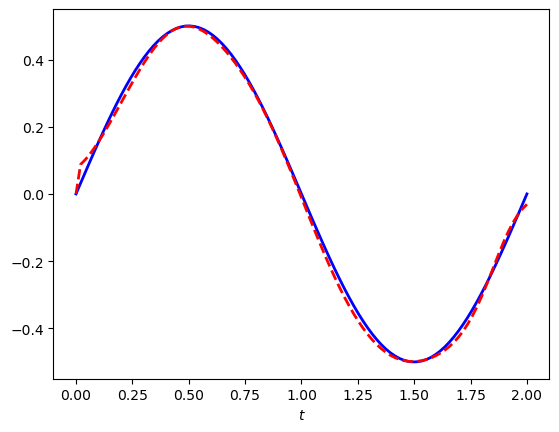

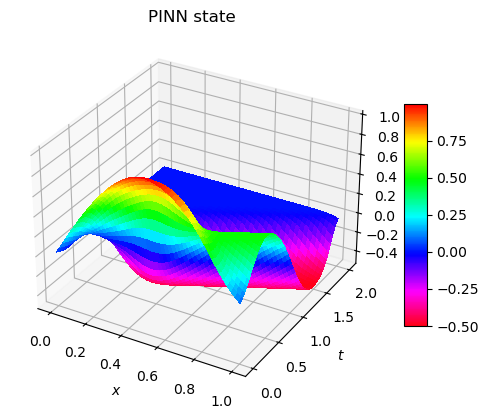

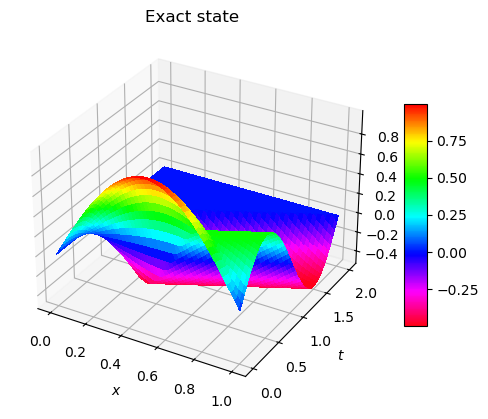

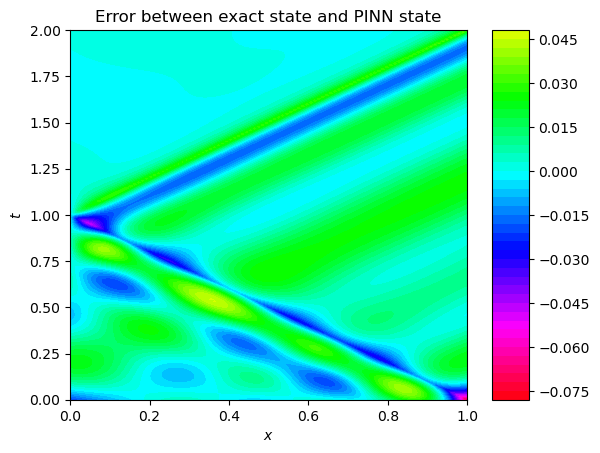

In [6]:
tt = np.linspace(0, 2, 100)
xx = np.ones_like(tt)
X = np.vstack((xx, tt)).T 
control_predict = np.ravel(model.predict(X)) # predicted control
control_predict[0] = 0 # at t=0 this value is known
    
control_exact = np.piecewise(tt, [tt<=1, tt>1], 
    [lambda tt: 0.5*np.sin(np.pi*(1-tt)), 
    lambda tt: -0.5*np.sin(np.pi*(tt-1))]) # exact control

gen_error_control = np.linalg.norm(control_predict-control_exact)
print('generalization error = ', gen_error_control)
relative_error_control = np.linalg.norm(control_predict-control_exact)/np.linalg.norm(control_exact)
print('relative error = ', relative_error_control)

fig = plt.figure()    
plt.plot(tt,control_exact, "-b",linewidth=2, label='Exact control')
plt.plot(tt,control_predict, "--r", linewidth=2, label='Predicted control')
plt.xlabel('$t$')
plt.show()

def auxiliary(z):
    y_exact = np.piecewise(z, [(z < -1) | (z > 1), (z >= -1) & (z <= 1)],
                                [lambda z: 0., lambda z: np.sin(np.pi * z)])
    return y_exact

def explicit_state(x1,t1):
    y_explicit = 0.5 * (auxiliary(x1-t1) 
                     + auxiliary(x1+t1))
    return y_explicit   # exact state

X = np.linspace(0, 1, 100)
t = np.linspace(0, 2, 200)

  
X_repeated = np.repeat(X,  t.shape[0])  # repeat each value of X the number of elements of t    
t_tiled = np.tile(t, X.shape[0]) # repeat the whole vector t, the number of elements of X    
XX = np.vstack((X_repeated, t_tiled)).T # stack them vertically and take the transpose

state_predict = model.predict(XX).T # predicted state
state_predict_M = state_predict.reshape((100,200)).T # predicted state in matrix form   

Xx, Tt = np.meshgrid(
    np.linspace(0, 1, 100),
    np.linspace(0, 2, 200)
    )

fig = plt.figure() # plot of predicted state
ax = plt.axes(projection="3d")
surf = ax.plot_surface(Xx,Tt, state_predict_M, 
                        cmap='hsv_r', linewidth=0, antialiased=False)
ax.set_title('PINN state ')
ax.set_xlabel('$x$')
ax.set_ylabel('$t$')
fig.colorbar(surf, shrink=0.6, aspect=10)    
plt.show()

state_exact = explicit_state(Xx, Tt) # computation of exact state

fig = plt.figure() # plot of exact state
ax = plt.axes(projection="3d")
surf2 = ax.plot_surface(Xx,Tt, state_exact, 
                        cmap='hsv_r', linewidth=0, antialiased=False)
ax.set_title('Exact state ')
ax.set_xlabel('$x$')
ax.set_ylabel('$t$')
fig.colorbar(surf2, shrink=0.6, aspect=10)    
plt.show()

error_state = state_exact-state_predict_M # error in state variable

fig, ax = plt.subplots() # plot of error in state variable
norm = cm.colors.Normalize(vmax=abs(error_state).max(), vmin=-abs(error_state).max())
cont = ax.contourf(Xx, Tt, error_state, 40,norm=norm, cmap='hsv_r')
ax.set_title('Error between exact state and PINN state')
ax.set_xlabel('$x$')
ax.set_ylabel('$t$') 
fig.colorbar(cont, shrink=1, aspect=10)
plt.show()